#### Plotting Gaussians in python 

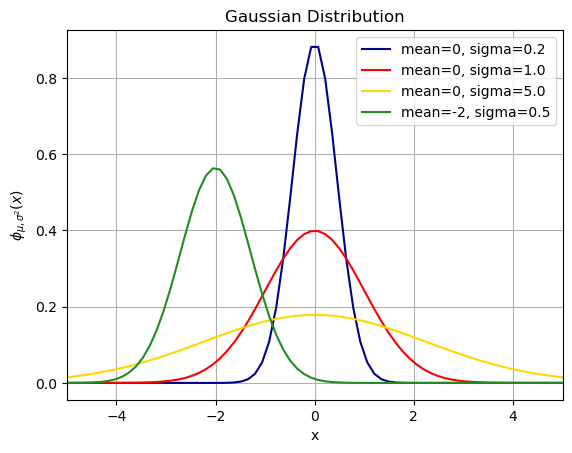

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters
mean_values = [0, 0, 0, -2]  # Mean values
sigma_values = [0.2, 1.0, 5.0, 0.5] # Standard deviation values
colors = ['darkblue', 'red', 'gold', 'forestgreen']
# Plotting
fig, ax = plt.subplots()

for i, (mean, sigma) in enumerate(zip(mean_values, sigma_values)):
    x = np.linspace(-7, 7, 100)
    y = norm.pdf(x, mean, np.sqrt(sigma))
    label = f"mean={mean}, sigma={sigma}"
    ax.plot(x, y, label=label, c=colors[i])

ax.set_xlabel('x')
ax.set_ylabel('$\phi_{\mu,\sigma^2}(x)$')
ax.set_xlim(-5, 5)
ax.set_title('Gaussian Distribution')
ax.legend()
plt.grid()
plt.show()


#### Chi square and mean squared error fits

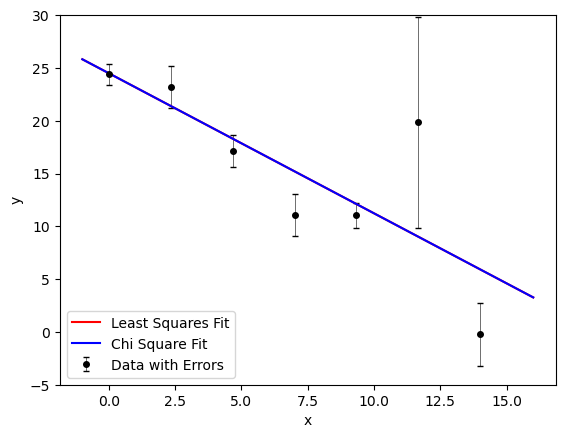

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def linear_func(x, m, c):
    return m * x + c


# Generate data
np.random.seed(42)
# x, y = generate_data_with_outliers()
# x = np.array([1.014, 2.964, 4.875, 6.786, 8.813, 10.763, 12.674])
x = np.linspace(0, 14, 7)
y = np.array([24.408, 23.166, 17.16, 11.05, 11.05, 19.852, -0.237])
erry = np.array([0.1, 0.2, 0.15, 0.2, 0.12, 1, 0.3])*10
# Calculate least squares fit
params_least_squares, _ = curve_fit(linear_func, x, y)

# Calculate chi-square fit
params_chi_square, _ = curve_fit(linear_func, x, y, method='lm')

m_least_squares, c_least_squares = params_least_squares
m_chi_square, c_chi_square = params_chi_square

# Calculate errors for least squares fit
#y_least_squares = linear_func(x, m_least_squares, c_least_squares)
#errors = (y - y_least_squares)**2

# Plotting
plt.errorbar(x, y, yerr=erry, fmt='o', label='Data with Errors', 
             capsize=2, elinewidth=0.4, markersize=4, c='k')
xplot = np.linspace(-1, 16, 9)
plt.plot(xplot, linear_func(xplot, m_least_squares, c_least_squares),
         color='r', label='Least Squares Fit')
plt.plot(xplot, linear_func(xplot, m_chi_square, c_chi_square),
         color='blue', label='Chi Square Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-5, 30)
# plt.xlim(0,14)
plt.legend()
plt.show()


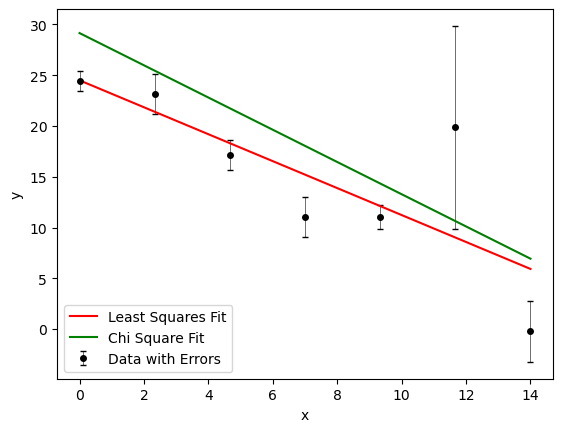

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.linspace(0, 14, 7)
y = np.array([24.408, 23.166, 17.16, 11.05, 11.05, 19.852, -0.237])
erry = np.array([0.1, 0.2, 0.15, 0.2, 0.12, 1, 0.3])*10

def linear_func(x, m, c):
    return m * x + c

# Calculate least squares fit
params_least_squares, _ = curve_fit(linear_func, x, y)

# Calculate chi-square fit
def chi_square_func(x, m, c):
    return (y - linear_func(x, m, c))**2



params_chi_square, _ = curve_fit(chi_square_func, x, y)

m_least_squares, c_least_squares = params_least_squares
m_chi_square, c_chi_square = params_chi_square

# Plotting
plt.errorbar(x, y, yerr=erry, fmt='o', label='Data with Errors', 
             capsize=2, elinewidth=0.4, markersize=4, c='k')
plt.plot(x, linear_func(x, m_least_squares, c_least_squares), color='r', label='Least Squares Fit')
plt.plot(x, linear_func(x, m_chi_square, c_chi_square), color='g', label='Chi Square Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


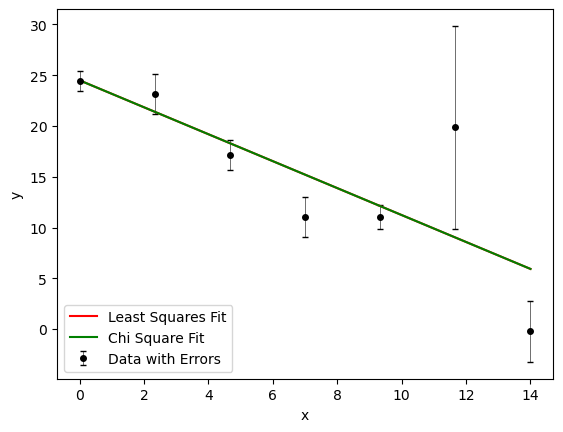

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 14, 7)
y = np.array([24.408, 23.166, 17.16, 11.05, 11.05, 19.852, -0.237])

def linear_func(x, m, c):
    return m * x + c

# Calculate least squares fit
A = np.vstack((x, np.ones_like(x))).T
params_least_squares, residuals, _, _ = np.linalg.lstsq(A, y, rcond=None)

# Calculate chi-square fit
def chi_square_func(params, x, y):
    m, c = params
    return np.sum((y - linear_func(x, m, c))**2)

from scipy.optimize import minimize
params_chi_square = minimize(chi_square_func, x0=[1, 1], args=(x, y)).x

m_least_squares, c_least_squares = params_least_squares
m_chi_square, c_chi_square = params_chi_square

# Plotting
plt.errorbar(x, y, yerr=erry, fmt='o', label='Data with Errors', 
             capsize=2, elinewidth=0.4, markersize=4, c='k')
plt.plot(x, linear_func(x, m_least_squares, c_least_squares), color='r', label='Least Squares Fit')
plt.plot(x, linear_func(x, m_chi_square, c_chi_square), color='g', label='Chi Square Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


#### Mean plot in python

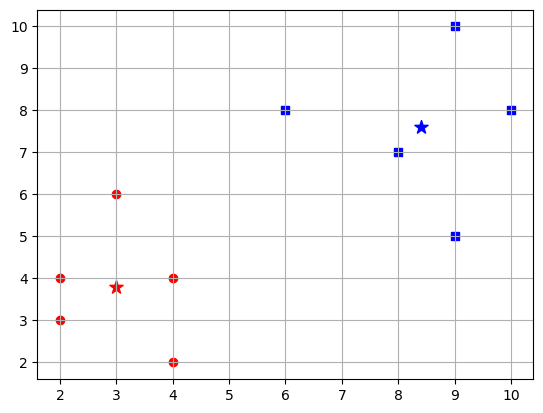

In [5]:
# Plot the data points

X1 = [4, 2, 2, 3, 4]
Y1 = [2, 4, 3, 6, 4]
X2 = [9,6,9, 8, 10]
Y2 = [10, 8, 5, 7, 8]

plt.figure()
plt.scatter(X1, Y1, c='red')
plt.scatter(np.mean(X1), np.mean(Y1), marker='*', c='red', s=100)
plt.scatter(X2, Y2, c='blue', marker='s')
plt.scatter(np.mean(X2), np.mean(Y2), marker='*', c='blue', s=100)
plt.grid()
plt.show()

#### Linear discriminant analysis

In [6]:
S1 = np.cov(X1, Y1)

In [7]:
S2 = np.cov(X2, Y2)


In [8]:
S1+S2

array([[ 3.3, -0.3],
       [-0.3,  5.5]])

#### LDA in python

In [9]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Define the points
X1 = [4, 2, 2, 3, 4]
Y1 = [2, 4, 3, 6, 4]
X2 = [9, 6, 9, 8, 10]
Y2 = [10, 8, 5, 7, 8]

# Combine the points into a single feature matrix
X = np.vstack((np.array(X1 + X2), np.array(Y1 + Y2))).T

# Create the corresponding target labels
y = np.array([0] * len(X1) + [1] * len(X2))
print(y)
# Perform Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

# Get the coefficients and intercept of the linear discriminant function
coefficients = lda.coef_
intercept = lda.intercept_

# Print the coefficients and intercept
print("Coefficients:", coefficients)
print("Intercept:", intercept)


[0 0 0 0 0 1 1 1 1 1]
Coefficients: [[3.41528239 1.56810631]]
Intercept: [-28.40531561]


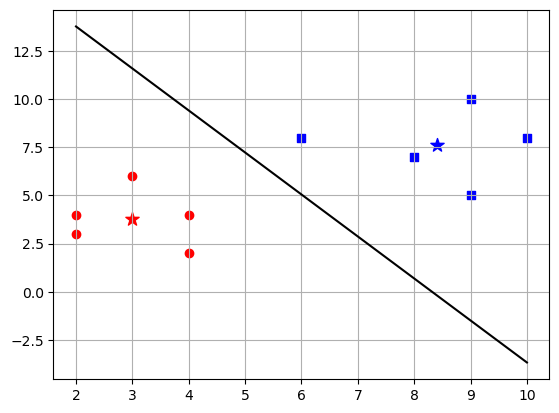

In [17]:
# Use coefficients and intercept to plot the separation line

line_x = np.array([np.min([X1, X2]), np.max([Y1, Y2])])
line_y = (-coefficients[0][0
] * line_x - intercept) / coefficients[0][1]
plt.figure()
plt.scatter(X1, Y1, c='red')
plt.scatter(np.mean(X1), np.mean(Y1), marker='*', c='red', s=100)
plt.scatter(X2, Y2, c='blue', marker='s')
plt.scatter(np.mean(X2), np.mean(Y2), marker='*', c='blue', s=100)
plt.plot(line_x, line_y, c='k')
plt.plot()
plt.grid()
plt.show()


#### Monte Carlo in Python

In [14]:
import numpy as np

def assign_classes(data):
    damage = {
        range(0, 10): "complex",
        range(10, 40): "double",
        range(40, 120): "no damage",
        range(120, 170): "single"
    }
    
    classes = np.empty(data.shape, dtype=object)
    
    for key, value in damage.items():
        classes[(data >= key.start) & (data < key.stop)] = value
    
    return classes

# Generate random data in the range (0, 170)
data = np.random.randint(low=0, high=170, size=100)

# Assign classes to the generated data
result = assign_classes(data)

# # Print the generated data and their assigned classes
# for i in range(len(data)):
#     print(f"Data: {data[i]}, Class: {result[i]}")



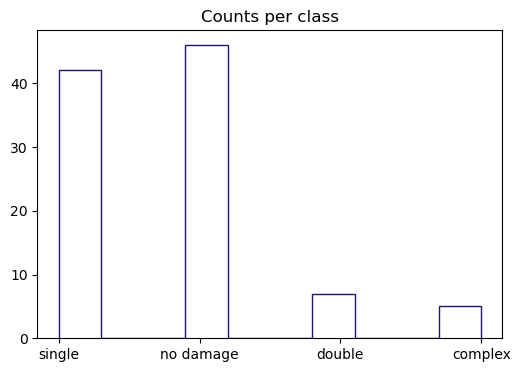

In [15]:
plt.figure(figsize=(6,4))
plt.title("Counts per class")
plt.hist(result, histtype=u'step', edgecolor='midnightblue')
plt.show()

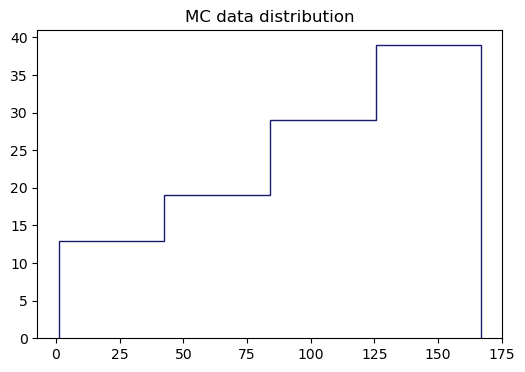

In [16]:
plt.figure(figsize=(6,4))
plt.title("MC data distribution")
plt.hist(data, bins=4, histtype=u'step', edgecolor='midnightblue')
plt.show()